# Example for helium dose calculation using pencilbeam engine.

This example demonstrates how to use the pyRadPlan library to perform helium dose calculations.

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/pencilbeam_helium.py

In [1]:
# Import necessary libraries
import logging

import numpy as np

from pyRadPlan import (
    IonPlan,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    plot_slice,
    load_tg119,
)

from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE

logging.basicConfig(level=logging.INFO)

D:\Python\pyRadPlan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load TG119 (provided within pyRadPlan)
ct, cst = load_tg119()

In this section, we create a helium therapy plan using the ParticleHongPencilBeamEngine.

In [3]:
# Create a plan object. The Mairani helium model ("HEL") derives alpha/beta from the LET of
# the Generic helium base data, so the plan reports RBE-weighted dose next to physical dose.
pln = IonPlan(radiation_mode="helium", machine="Generic", bio_model="HEL")
pln.prop_opt = {"solver": "scipy"}

# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

# Calculate optimized fluence
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Compute the result on the CT grid
result = dij.compute_result_ct_grid(fluence)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

Beam: 100%|██████████| 1/1 [00:01<00:00,  1.64s/b]

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid not set. Using default resolution.


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (101,101,65) with resolution x=5.000000, y=5.000000, z=5.000000.


...

INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:507 Objective function evaluations, avg. time: 0.0150574 +/- 0.0175896 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:507 Derivative evaluations, avg. time: 0.0281761 +/- 0.0119267 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 23.6028 s


Visualize the results

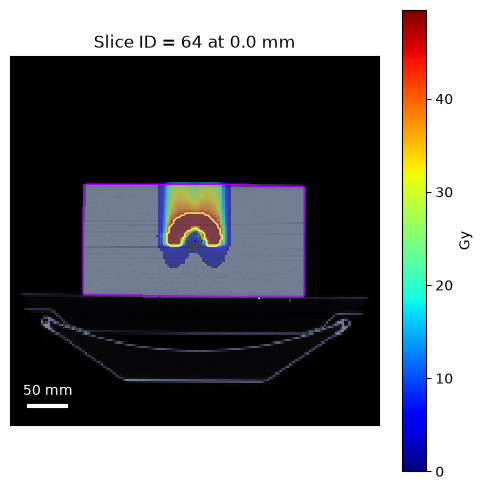

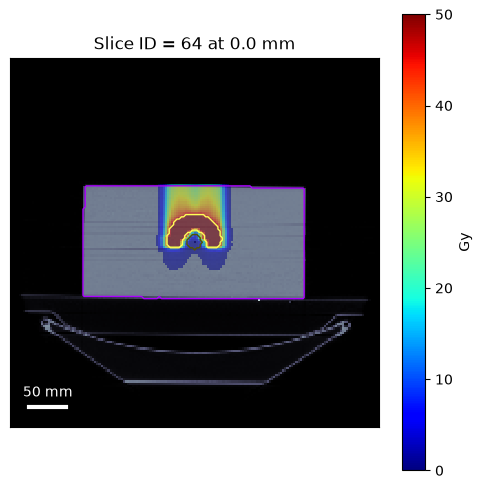

In [4]:
if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result)
else:
    # Choose a slice to visualize
    view_slice = int(np.round(ct.size[2] / 2))

    # Visualize physical and RBE-weighted dose
    plot_slice(
        image_volume=ct,
        cst=cst,
        overlay=result["physical_dose"],
        view_slice=view_slice,
        plane="axial",
        overlay_unit="Gy",
    )
    plot_slice(
        image_volume=ct,
        cst=cst,
        overlay=result["rbe_x_dose"],
        view_slice=view_slice,
        plane="axial",
        overlay_unit="Gy",
    )